# Visualizações Interativas - Demonstrações Financeiras CVM 2024

Neste notebook, todos os gráficos são interativos via Plotly.  
Você poderá explorar hover, filtros e zoom nos indicadores financeiros

In [24]:
# 0️. Importação de bibliotecas e conexão
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import seaborn as sns

engine_cvm = create_engine('sqlite:///data_cvm.db')

def query_sql(query_string):
    with engine_cvm.connect() as con:
        return pd.read_sql(text(query_string), con=con)

## 1️. Top 10 Empresas por ROE

Exibe as empresas que entregaram maior retorno sobre patrimônio líquido em 2024.

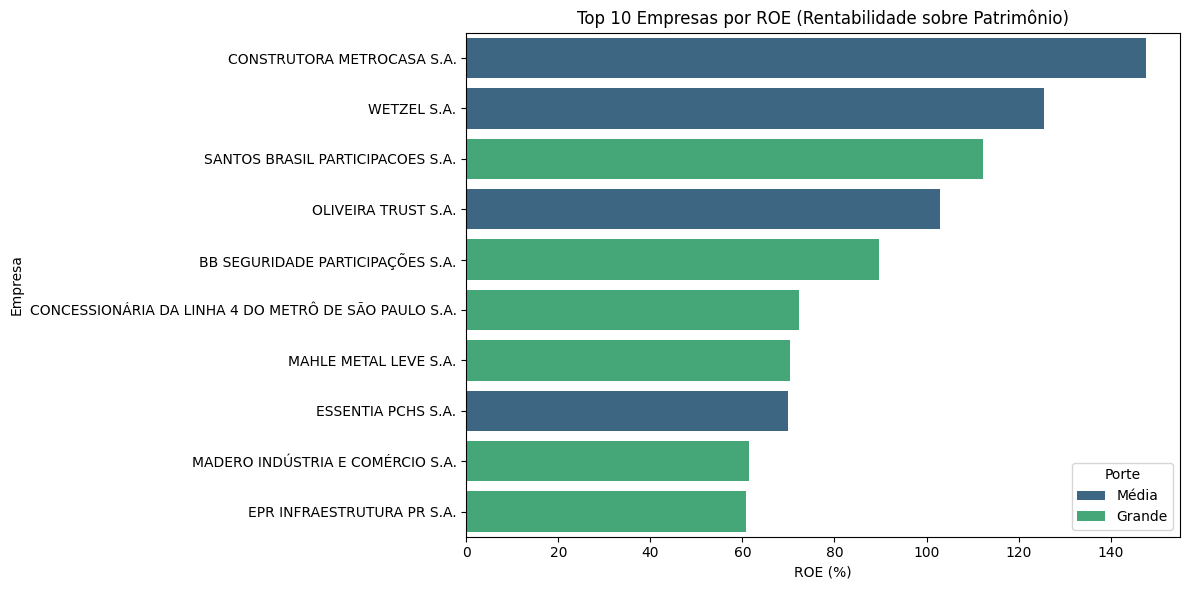

In [25]:
query_top_roe = """
SELECT DENOM_CIA, ROE, PORTE_EMPRESA
FROM empresas_cvm
WHERE ROE IS NOT NULL
"""
df_top_roe = query_sql(query_top_roe)
df_top_roe = df_top_roe[(df_top_roe['ROE'] > -50) & (df_top_roe['ROE'] < 200)]
df_top_roe = df_top_roe.sort_values('ROE', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x='ROE',
    y='DENOM_CIA',
    data=df_top_roe,
    hue='PORTE_EMPRESA',
    dodge=False,
    palette='viridis'
)
plt.title('Top 10 Empresas por ROE (Rentabilidade sobre Patrimônio)')
plt.xlabel('ROE (%)')
plt.ylabel('Empresa')
plt.legend(title='Porte')
plt.tight_layout()
plt.savefig("top_roe.png")
plt.show()

**Insight:**  
Permite identificar rapidamente as empresas mais eficientes para o acionista, visualizando porte e ROE em hover.

## 2️. Receita de Venda x Lucro Líquido (Interativo)
Mostra correlação entre receita e lucro, permitindo identificar empresas com alta receita mas baixa rentabilidade.

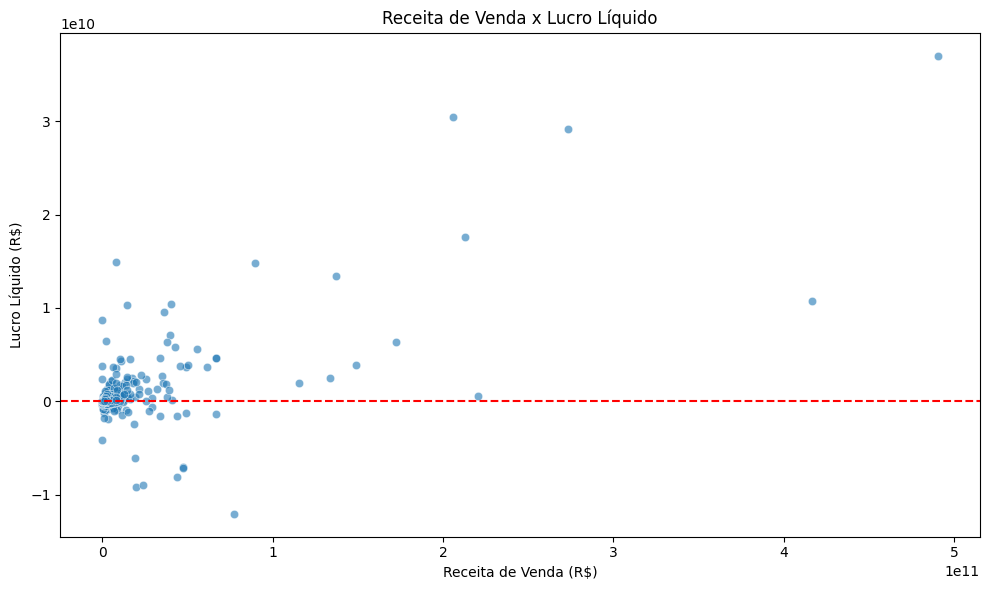

In [26]:
query_relacao = """
SELECT RECEITA_VENDA, LUCRO_LÍQUIDO, DENOM_CIA, PORTE_EMPRESA, ATIVO_TOTAL
FROM empresas_cvm
"""
df_rel = query_sql(query_relacao)

plt.figure(figsize=(10,6))
sns.scatterplot(
    x='RECEITA_VENDA',
    y='LUCRO_LÍQUIDO',
    data=df_rel,
    alpha=0.6
)
plt.title('Receita de Venda x Lucro Líquido')
plt.xlabel('Receita de Venda (R$)')
plt.ylabel('Lucro Líquido (R$)')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.savefig("receita_lucro.png")
plt.show()

**Insight:**  
Ajuda a identificar empresas grandes com baixa margem ou prejuízo, destacando risco operacional.

## 3️. Distribuição da Margem Líquida (Interativo)

Visualiza como as margens líquidas se distribuem entre empresas, por porte.

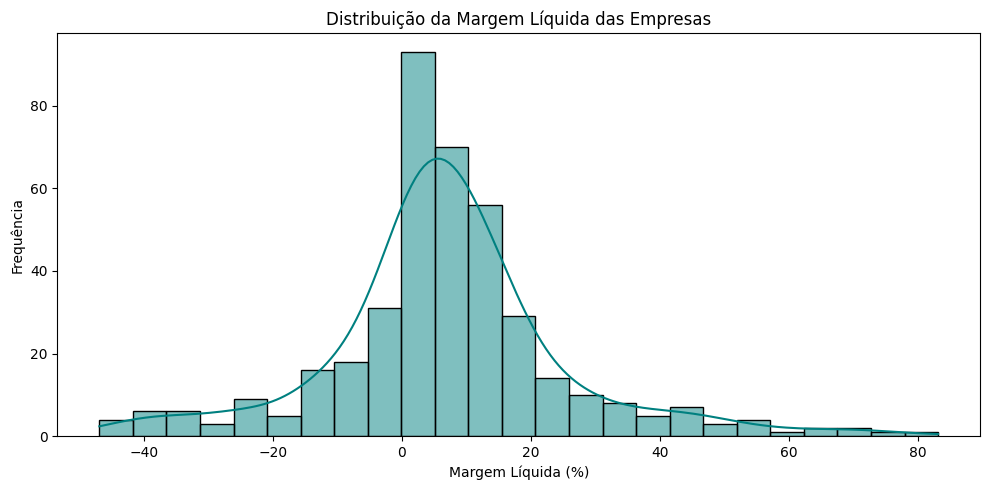

In [27]:
query_margem = """
SELECT MARGEM_LÍQUIDA, PORTE_EMPRESA
FROM empresas_cvm
WHERE MARGEM_LÍQUIDA BETWEEN -50 AND 100
"""
df_margem = query_sql(query_margem)

plt.figure(figsize=(10,5))
sns.histplot(
    df_margem['MARGEM_LÍQUIDA'],
    bins=25,
    kde=True,
    color='teal'
)
plt.title('Distribuição da Margem Líquida das Empresas')
plt.xlabel('Margem Líquida (%)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.savefig("margem_liquida.png")
plt.show()

**Insight:**  
Permite ver concentração de margens positivas e negativas, identificar porte e avaliar eficiência operacional.

## 4️. Comparação de ROE por Porte de Empresa (Interativo)

Boxplot interativo com swarmplot embutido para visualizar dispersão e outliers.

/tmp/ipykernel_769/541761877.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




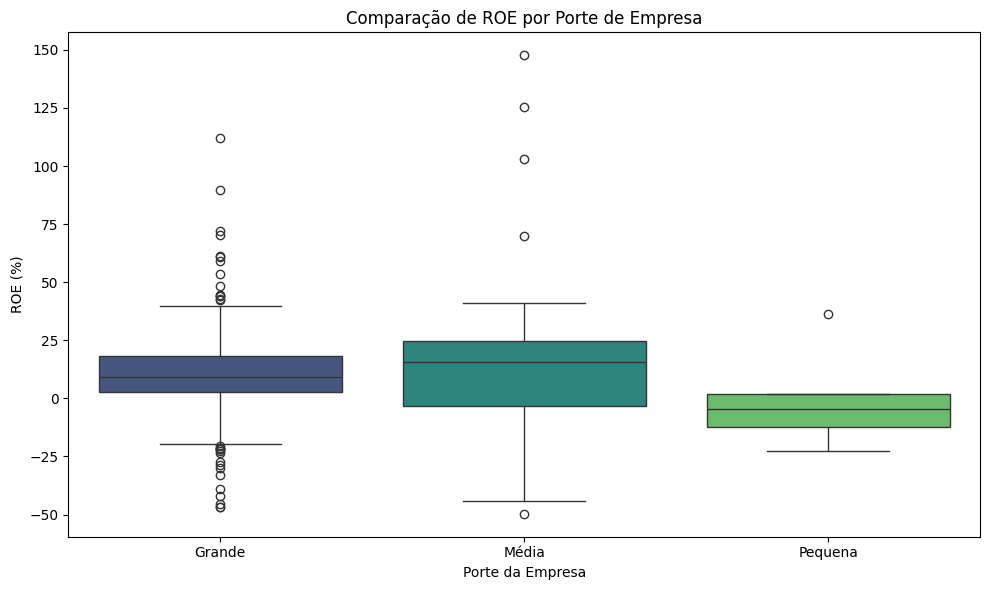

In [28]:
query_geral = """
SELECT PORTE_EMPRESA, ROE, DENOM_CIA
FROM empresas_cvm
"""
df_para_grafico = query_sql(query_geral)
df_para_grafico = df_para_grafico[(df_para_grafico['ROE'] > -50) & (df_para_grafico['ROE'] < 200)]

plt.figure(figsize=(10,6))
sns.boxplot(
    x='PORTE_EMPRESA',
    y='ROE',
    data=df_para_grafico,
    palette='viridis'
)
plt.title('Comparação de ROE por Porte de Empresa')
plt.xlabel('Porte da Empresa')
plt.ylabel('ROE (%)')
plt.tight_layout()
plt.savefig("roe_por_porte.png")
plt.show()

**Insight:**  
Permite comparar dispersão, outliers e eficiência entre diferentes portes de empresa, destacando risco e oportunidades para acionistas.